In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
import numpy as np
import matplotlib.pyplot as plt


In [99]:
df = pd.read_csv('/content/patient1_glucose.csv')
print("DataFrame loaded successfully.")

print("\nFirst 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame information:")
df.info()

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

DataFrame loaded successfully.

First 5 rows of the DataFrame:
  Patient_ID Measurement_date Measurement_time  Measurement
0  LIB193263       2020-06-09         19:08:00           99
1  LIB193263       2020-06-09         19:23:00           92
2  LIB193263       2020-06-09         19:38:00           86
3  LIB193263       2020-06-09         19:53:00           85
4  LIB193263       2020-06-09         20:08:00           85

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60098 entries, 0 to 60097
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        60098 non-null  object
 1   Measurement_date  60098 non-null  object
 2   Measurement_time  60098 non-null  object
 3   Measurement       60098 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.8+ MB

Descriptive statistics of the DataFrame:
        Measurement
count  60098.000000
mean     177.817248
std       62.6993

Created 'datetime' column and converted to datetime type.
Set 'datetime' as DataFrame index.
DataFrame sorted by datetime index.
Calculated time differences.

Distribution of sampling intervals:
datetime
0 days 00:15:00    57195
0 days 00:16:00     1549
0 days 00:17:00      481
0 days 00:14:00      220
0 days 00:18:00       67
                   ...  
0 days 01:42:00        1
0 days 04:15:00        1
0 days 01:25:00        1
0 days 02:02:00        1
0 days 09:15:00        1
Name: count, Length: 95, dtype: int64


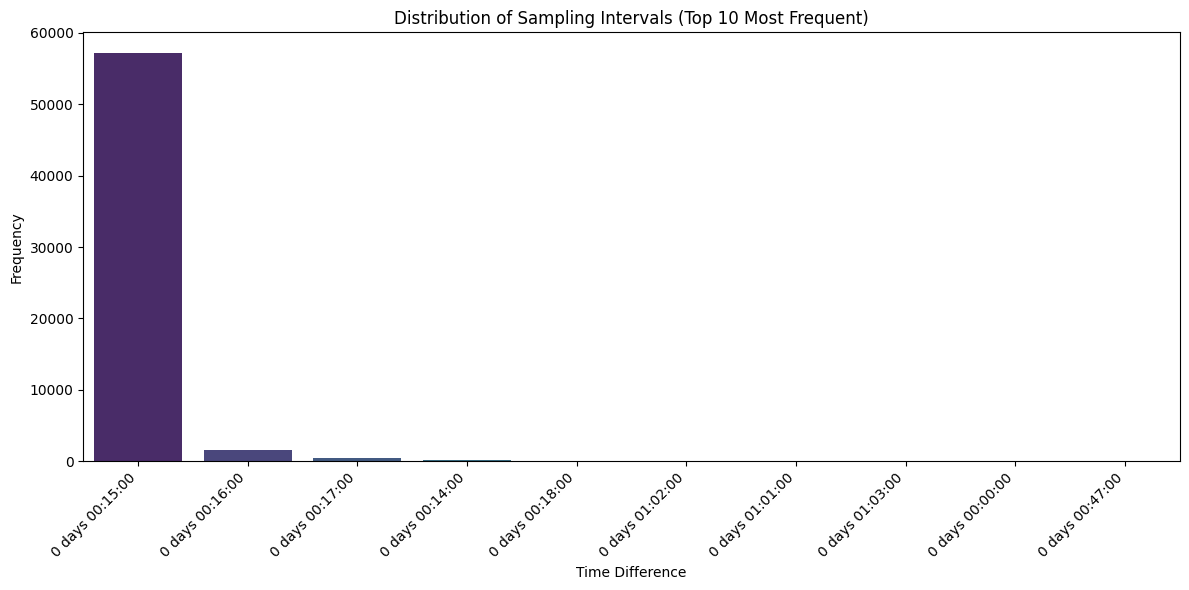

Visualized sampling interval distribution.


In [100]:
# 1. New column = 'Measurement_date' + 'Measurement_time' (datetime column)
df['datetime'] = pd.to_datetime(df['Measurement_date'] + ' ' + df['Measurement_time'])
print("Created 'datetime' column and converted to datetime type.")

# 2. Set the datetime column as index (since it is a timeseries dataset)
df = df.set_index('datetime')
print("Set 'datetime' as DataFrame index.")

# 3. Sort for temporal ordering
df = df.sort_index()
print("DataFrame sorted by datetime index.")

# 4. Calculate the time differences for index column
time_diffs = df.index.to_series().diff().dropna()
print("Calculated time differences.")

# 5. Print sampling intervals
print("\nDistribution of sampling intervals:")
print(time_diffs.value_counts())

# 6. Create a histogram or bar plot to visualize the distribution of these time differences
# Limiting to top 10 most frequent intervals for better visualization if there are many unique values
top_n = 10
if len(time_diffs.value_counts()) > top_n:
    # Consider only the top N most frequent time differences for plotting
    plot_data = time_diffs.value_counts().head(top_n)
    title_suffix = f' (Top {top_n} Most Frequent)'
else:
    plot_data = time_diffs.value_counts()
    title_suffix = ''

plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index.astype(str), y=plot_data.values, palette='viridis')
plt.title(f'Distribution of Sampling Intervals{title_suffix}')
plt.xlabel('Time Difference')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Visualized sampling interval distribution.")

In [101]:
# Outliers Check (Statistics wise)
Q1 = df['Measurement'].quantile(0.25)
Q3 = df['Measurement'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Measurement'] < lower_bound) | (df['Measurement'] > upper_bound)]

print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Number of outliers detected: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")

Lower Bound for Outliers: 1.50
Upper Bound for Outliers: 349.50
Number of outliers detected: 496
Percentage of outliers: 0.83%


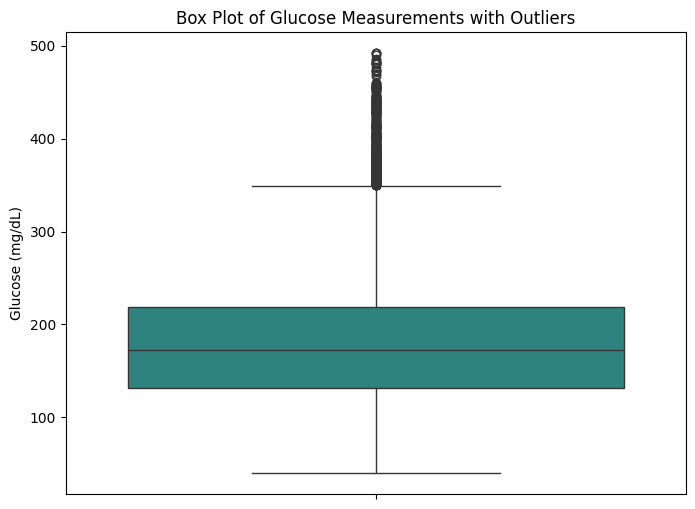

Box plot of glucose measurements with outliers visualized.


In [102]:
# Outliers visually
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Measurement'], palette='viridis')
plt.title('Box Plot of Glucose Measurements with Outliers')
plt.ylabel('Glucose (mg/dL)')
plt.show()
print("Box plot of glucose measurements with outliers visualized.")

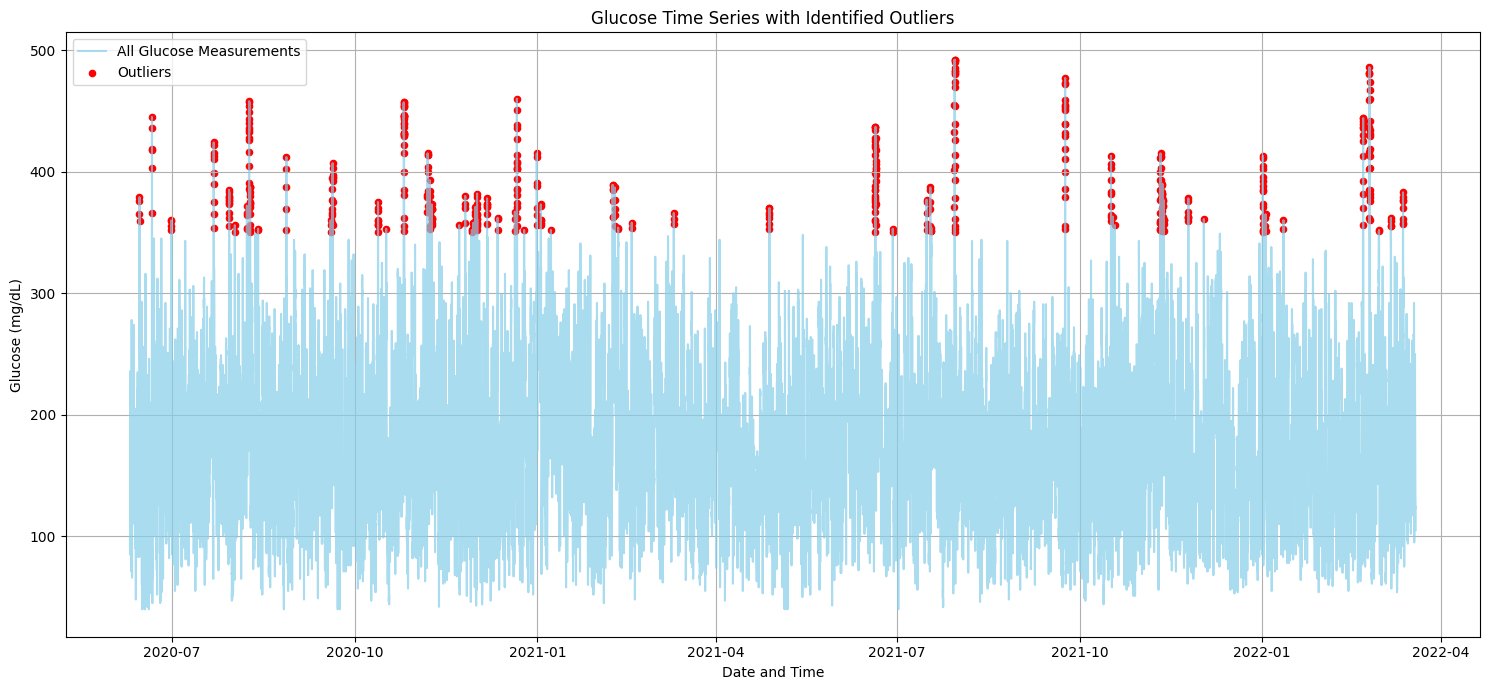

Glucose time series plot with outliers visualized.


In [103]:
# highlighting outliers
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Measurement'], label='All Glucose Measurements', color='skyblue', alpha=0.7)
plt.scatter(outliers.index, outliers['Measurement'], color='red', s=20, label='Outliers')
plt.title('Glucose Time Series with Identified Outliers')
plt.xlabel('Date and Time')
plt.ylabel('Glucose (mg/dL)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Glucose time series plot with outliers visualized.")

In [104]:
# 1. Resample the DataFrame df to a 15-minute frequency, taking the mean of the 'Measurement' column for each interval.
df_resampled = df['Measurement'].resample('15min').mean()

# 2. Fill any missing values in the resampled DataFrame using forward-fill (fill).
df_resampled = df_resampled.ffill()
print("DataFrame resampled to 15-minute frequency and missing values forward-filled.")

# Create a new DataFrame for feature engineering
df_processed = pd.DataFrame(df_resampled)
df_processed.columns = ['glucose']

# 4. Create a new column named 'glucose_diff_1' representing the difference between the current glucose measurement and the previous one.
df_processed['glucose_diff_1'] = df_processed['glucose'].diff(1)

# 5. Create additional lagged features for glucose
# lag_1: 15 minutes prior
df_processed['lag_1'] = df_processed['glucose'].shift(1)
# lag_4: 1 hour prior (4 * 15 minutes)
df_processed['lag_4'] = df_processed['glucose'].shift(4)
# lag_12: 3 hours prior (12 * 15 minutes)
df_processed['lag_12'] = df_processed['glucose'].shift(12)
# lag_24: 6 hours prior (24 * 15 minutes)
df_processed['lag_24'] = df_processed['glucose'].shift(24)

# 6. Drop any rows that contain NaN values resulting from the lag feature creation.
df_processed.dropna(inplace=True)

print("Features 'glucose_diff_1', 'lag_1', 'lag_4', 'lag_12', and 'lag_24' created and NaN rows dropped.")

# Display the first few rows of the processed DataFrame
print("\nFirst 5 rows of the processed DataFrame with new features:")
print(df_processed.head())

# Display the info of the processed DataFrame
print("\nDataFrame information after feature engineering:")
df_processed.info()

DataFrame resampled to 15-minute frequency and missing values forward-filled.
Features 'glucose_diff_1', 'lag_1', 'lag_4', 'lag_12', and 'lag_24' created and NaN rows dropped.

First 5 rows of the processed DataFrame with new features:
                     glucose  glucose_diff_1  lag_1  lag_4  lag_12  lag_24
datetime                                                                  
2020-06-10 01:00:00    192.0           -11.0  203.0  224.0   206.0    99.0
2020-06-10 01:15:00    176.0           -16.0  192.0  219.0   223.0    92.0
2020-06-10 01:30:00    163.0           -13.0  176.0  213.0   234.0    86.0
2020-06-10 01:45:00    152.0           -11.0  163.0  203.0   236.0    85.0
2020-06-10 02:00:00    146.0            -6.0  152.0  192.0   228.0    85.0

DataFrame information after feature engineering:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 62139 entries, 2020-06-10 01:00:00 to 2022-03-19 07:30:00
Freq: 15min
Data columns (total 6 columns):
 #   Column          Non-Null Coun

In [105]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler to the df_processed DataFrame and transform the data
X_scaled = scaler.fit_transform(df_processed)

print("Data scaled using StandardScaler.")
print("Shape of scaled data (X_scaled):", X_scaled.shape)
print("First 5 rows of scaled data (X_scaled):")
print(X_scaled[:5])

Data scaled using StandardScaler.
Shape of scaled data (X_scaled): (62139, 6)
First 5 rows of scaled data (X_scaled):
[[ 0.22184704 -0.94631744  0.39660311  0.7302035   0.44400468 -1.25591181]
 [-0.03237454 -1.37652341  0.2218241   0.6507575   0.71412297 -1.36712471]
 [-0.23892957 -1.11839983 -0.03239991  0.55542231  0.88890539 -1.46245006]
 [-0.4137069  -0.94631744 -0.23895691  0.39653032  0.92068401 -1.47833762]
 [-0.50903999 -0.51611147 -0.41373592  0.22174913  0.79356952 -1.47833762]]


In [106]:
total_samples = X_scaled.shape[0]
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# Split points
train_end = train_size
val_end = train_size + val_size

# Create training, validation, and test sets
X_train = X_scaled[:train_end]
X_val = X_scaled[train_end:val_end]
X_test = X_scaled[val_end:]

print(f"Shape of X_scaled: {X_scaled.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_scaled: (62139, 6)
Shape of X_train: (43497, 6)
Shape of X_val: (9320, 6)
Shape of X_test: (9322, 6)


In [113]:
def classify_glucose(glucose_value):
    if glucose_value < 70:
        return 'hypoglycemia'
    elif 70 <= glucose_value <= 180:
        return 'normoglycemia'
    else:
        return 'hyperglycemia'

# Apply the classification function to both actual and predicted glucose values
forecast_df['actual_category'] = forecast_df['actual_glucose'].apply(classify_glucose)
forecast_df['predicted_category'] = forecast_df['predicted_glucose'].apply(classify_glucose)

# Calculate the accuracy: percentage of times the predicted category matches the actual category
category_accuracy = (forecast_df['actual_category'] == forecast_df['predicted_category']).mean() * 100

print(f"Classification Accuracy (based on physiological ranges): {category_accuracy:.2f}%")

# Display a sample of the categorized results
print("\nSample of Categorized Forecasts:")
print(forecast_df[['actual_glucose', 'predicted_glucose', 'actual_category', 'predicted_category']].head())

Classification Accuracy (based on physiological ranges): 93.39%

Sample of Categorized Forecasts:
                     actual_glucose  predicted_glucose actual_category  \
datetime                                                                 
2021-12-12 05:15:00           204.0         198.749698   hyperglycemia   
2021-12-12 05:30:00           206.0         198.749698   hyperglycemia   
2021-12-12 05:45:00           196.0         198.749698   hyperglycemia   
2021-12-12 06:00:00           188.0         198.749698   hyperglycemia   
2021-12-12 06:15:00           190.0         198.749698   hyperglycemia   

                    predicted_category  
datetime                                
2021-12-12 05:15:00      hyperglycemia  
2021-12-12 05:30:00      hyperglycemia  
2021-12-12 05:45:00      hyperglycemia  
2021-12-12 06:00:00      hyperglycemia  
2021-12-12 06:15:00      hyperglycemia  


Evaluating HMMs with 6 features on validation set of size 9320.
Number of States: 2, Log-Likelihood: -64094.35, BIC: 128435.48, Num_params: 27
Number of States: 3, Log-Likelihood: -57372.69, BIC: 115147.54, Num_params: 44
Number of States: 4, Log-Likelihood: -52752.09, BIC: 106079.99, Num_params: 63
Number of States: 5, Log-Likelihood: -49824.22, BIC: 100416.18, Num_params: 84
Number of States: 6, Log-Likelihood: -47351.82, BIC: 95681.60, Num_params: 107
Number of States: 7, Log-Likelihood: -45664.31, BIC: 92535.08, Num_params: 132
Number of States: 8, Log-Likelihood: -44115.63, BIC: 89684.51, Num_params: 159
Number of States: 9, Log-Likelihood: -42483.64, BIC: 86685.58, Num_params: 188
Number of States: 10, Log-Likelihood: -40813.67, BIC: 83628.99, Num_params: 219
Finished evaluating HMMs for different numbers of hidden states.


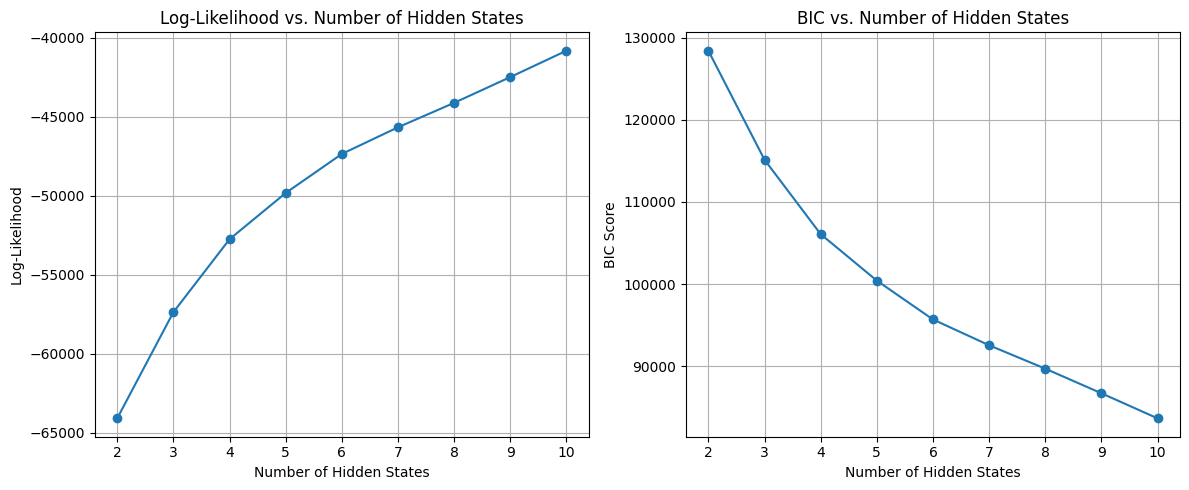

Optimal number of hidden states based on BIC: 10
Final GaussianHMM model trained with 10 hidden states.


In [108]:
# Define the range of hidden states to evaluate
min_states = 2
max_states = 10
possible_n_states = range(min_states, max_states + 1)

# Initialize lists to store metrics
log_likelihoods = []
bic_scores = []

n_features = X_train.shape[1] # Number of features in the data
num_samples_val = X_val.shape[0] # Number of samples in the validation set

print(f"Evaluating HMMs with {n_features} features on validation set of size {num_samples_val}.")

for n_components in possible_n_states:
    # Calculate the number of parameters for BIC
    # For GaussianHMM with 'diag' covariance:
    # n_components initial probabilities: (n_components - 1) free parameters
    # n_components * n_components transition probabilities: n_components * (n_components - 1) free parameters
    # n_components * n_features means
    # n_components * n_features for diagonal covariance matrices

    num_params = (n_components - 1) + \
                 (n_components * (n_components - 1)) + \
                 (n_components * n_features) + \
                 (n_components * n_features)

    # Instantiate and train GaussianHMM model with 'diag' covariance type
    # Increased n_iter for better convergence and added verbose=True to see training progress
    model = hmm.GaussianHMM(n_components=n_components, covariance_type='diag', n_iter=200, random_state=42, verbose=False)

    # Train the model on the training data
    model.fit(X_train)

    # Calculate log-likelihood on the validation data
    log_likelihood = model.score(X_val)
    log_likelihoods.append(log_likelihood)

    # Calculate BIC
    bic = -2 * log_likelihood + num_params * np.log(num_samples_val)
    bic_scores.append(bic)

    print(f"Number of States: {n_components}, Log-Likelihood: {log_likelihood:.2f}, BIC: {bic:.2f}, Num_params: {num_params}")

print("Finished evaluating HMMs for different numbers of hidden states.")

# Plotting log-likelihoods and BIC scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(possible_n_states, log_likelihoods, marker='o')
plt.title('Log-Likelihood vs. Number of Hidden States')
plt.xlabel('Number of Hidden States')
plt.ylabel('Log-Likelihood')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(possible_n_states, bic_scores, marker='o')
plt.title('BIC vs. Number of Hidden States')
plt.xlabel('Number of Hidden States')
plt.ylabel('BIC Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Select the optimal number of hidden states based on BIC (lower is better)
optimal_n_states = possible_n_states[np.argmin(bic_scores)]
print(f"Optimal number of hidden states based on BIC: {optimal_n_states}")

# Train the final GaussianHMM model with the optimal number of states
final_hmm_model = hmm.GaussianHMM(n_components=optimal_n_states, covariance_type='diag', n_iter=200, random_state=42, verbose=False)
final_hmm_model.fit(X_train)
print(f"Final GaussianHMM model trained with {optimal_n_states} hidden states.")

# You can also store the model for later use, e.g., in a dictionary or directly
# For this step, we just train it. In a later step, we might save it.

In [109]:
val_ll = final_hmm_model.score(X_val)
print(f"Validation Log-Likelihood for the final HMM model: {val_ll:.2f}")

Validation Log-Likelihood for the final HMM model: -40813.67


In [110]:
import pandas as pd
import numpy as np

# 1. Extract the actual 'glucose' values from the df_processed DataFrame that correspond to the X_test period.
# The X_test corresponds to the slice of df_processed from val_end onwards.
actual_test_glucose = df_processed['glucose'][val_end:]

# 2. Use the final_hmm_model.predict() method on X_test to get the most likely sequence of hidden states for the test data.
predicted_states_test = final_hmm_model.predict(X_test)
print(f"Predicted states for test set shape: {predicted_states_test.shape}")

# 3. Access the means_ attribute of the final_hmm_model.
# 4. Map the predicted_states_test to their corresponding scaled mean 'glucose' values.
# The 'glucose' feature is the first column (index 0) in the original df_processed, so it's also the first feature in the HMM model.
predicted_scaled_glucose_means = final_hmm_model.means_[predicted_states_test, 0]
print(f"Predicted scaled glucose means shape: {predicted_scaled_glucose_means.shape}")

# 5. Inverse transform these predicted_scaled_glucose_means values back to the original scale using the scaler object.
# Create a dummy array with the same number of features as the original data used for scaling
dummy_array = np.zeros((predicted_scaled_glucose_means.shape[0], X_test.shape[1]))
# Place the predicted scaled glucose values into the first column of the dummy array
dummy_array[:, 0] = predicted_scaled_glucose_means

# Inverse transform the dummy array
inverse_transformed_array = scaler.inverse_transform(dummy_array)

# Extract the first column (glucose) after inverse transformation
predicted_glucose = inverse_transformed_array[:, 0]
print(f"Predicted glucose (inverse transformed) shape: {predicted_glucose.shape}")

# 6. Create a DataFrame, forecast_df, that contains the datetime index for the test set, the actual_test_glucose, and the predicted_glucose.
forecast_df = pd.DataFrame({
    'actual_glucose': actual_test_glucose.values,
    'predicted_glucose': predicted_glucose
}, index=actual_test_glucose.index)

print("\nFirst 5 rows of the forecast DataFrame:")
print(forecast_df.head())
print("Forecast of glucose values on test set completed.")

Predicted states for test set shape: (9322,)
Predicted scaled glucose means shape: (9322,)
Predicted glucose (inverse transformed) shape: (9322,)

First 5 rows of the forecast DataFrame:
                     actual_glucose  predicted_glucose
datetime                                              
2021-12-12 05:15:00           204.0         198.749698
2021-12-12 05:30:00           206.0         198.749698
2021-12-12 05:45:00           196.0         198.749698
2021-12-12 06:00:00           188.0         198.749698
2021-12-12 06:15:00           190.0         198.749698
Forecast of glucose values on test set completed.


In [111]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Extract actual and predicted values
actual_glucose = forecast_df['actual_glucose']
predicted_glucose = forecast_df['predicted_glucose']

# 2. Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_glucose, predicted_glucose))

# 3. Calculate MAE
mae = mean_absolute_error(actual_glucose, predicted_glucose)

# 4. Print the results
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Root Mean Squared Error (RMSE): 18.68
Mean Absolute Error (MAE): 12.57


In [112]:
# Access the means of each state for all features
state_means_scaled = final_hmm_model.means_
# Access the variances of each state for all features (diagonal elements only for 'diag' cov type)
state_covars_scaled = final_hmm_model.covars_

# Extract scaled mean glucose for each state (first feature is glucose)
scaled_glucose_means = state_means_scaled[:, 0]

# Extract scaled standard deviation of glucose for each state
# For 'diag' covariance, covars_[i, j, j] is the variance of feature j in state i
scaled_glucose_stds = np.sqrt(state_covars_scaled[:, 0, 0])

# Inverse transform the scaled glucose means
# Create a dummy array for inverse transformation, only filling the first feature (glucose)
# The other features are set to 0, but since StandardScaler operates independently on features
# and we are only interested in the first column after inverse_transform, this is fine.

dummy_means_array = np.zeros_like(state_means_scaled)
dummy_means_array[:, 0] = scaled_glucose_means
unscaled_glucose_means = scaler.inverse_transform(dummy_means_array)[:, 0]

# Inverse transform the scaled glucose standard deviations
# StandardScaler scales by (X - mean) / std. So, scaled_std = original_std / scaler.scale_[0]
# Therefore, original_std = scaled_std * scaler.scale_[0]
unscaled_glucose_stds = scaled_glucose_stds * scaler.scale_[0]

# Print the characteristics and provide physiological interpretation
print("Physiological Interpretation of Hidden States:")
print("-------------------------------------------")

state_stats = []
for i in range(final_hmm_model.n_components):
    mean_glucose = unscaled_glucose_means[i]
    std_glucose = unscaled_glucose_stds[i]

    interpretation = ""
    if mean_glucose < 70:
        interpretation = "Hypoglycemia (Low Glucose)"
    elif 70 <= mean_glucose <= 180:
        interpretation = "Normoglycemia / Controlled Hyperglycemia (Normal to Slightly Elevated Glucose)"
    else:
        interpretation = "Hyperglycemia (High Glucose)"

    state_stats.append({
        "state": i,
        "mean_glucose": mean_glucose,
        "std_glucose": std_glucose,
        "interpretation": interpretation
    })

    print(f"State {i}: Mean Glucose = {mean_glucose:.2f} mg/dL, Std Dev Glucose = {std_glucose:.2f} mg/dL - Interpretation: {interpretation}")

# Sort states by mean glucose for better comparison
sorted_state_stats = sorted(state_stats, key=lambda x: x['mean_glucose'])

print("\nStates sorted by mean glucose:")
for stat in sorted_state_stats:
    print(f"State {stat['state']}: Mean Glucose = {stat['mean_glucose']:.2f} mg/dL, Std Dev Glucose = {stat['std_glucose']:.2f} mg/dL - Interpretation: {stat['interpretation']}")

Physiological Interpretation of Hidden States:
-------------------------------------------
State 0: Mean Glucose = 141.85 mg/dL, Std Dev Glucose = 18.33 mg/dL - Interpretation: Normoglycemia / Controlled Hyperglycemia (Normal to Slightly Elevated Glucose)
State 1: Mean Glucose = 118.16 mg/dL, Std Dev Glucose = 10.04 mg/dL - Interpretation: Normoglycemia / Controlled Hyperglycemia (Normal to Slightly Elevated Glucose)
State 2: Mean Glucose = 269.82 mg/dL, Std Dev Glucose = 15.35 mg/dL - Interpretation: Hyperglycemia (High Glucose)
State 3: Mean Glucose = 198.75 mg/dL, Std Dev Glucose = 12.18 mg/dL - Interpretation: Hyperglycemia (High Glucose)
State 4: Mean Glucose = 205.91 mg/dL, Std Dev Glucose = 16.83 mg/dL - Interpretation: Hyperglycemia (High Glucose)
State 5: Mean Glucose = 311.87 mg/dL, Std Dev Glucose = 50.48 mg/dL - Interpretation: Hyperglycemia (High Glucose)
State 6: Mean Glucose = 150.92 mg/dL, Std Dev Glucose = 12.24 mg/dL - Interpretation: Normoglycemia / Controlled Hyperg